# COVID-19 Radiography Dataset  
## Exploratory Data Analysis (EDA)

---

### Prepared by: 
**Ziad Bahaa Elsayed**

### Role:  
EDA & Documentation Lead (Task 2)

### Dataset: 
COVID-19 Radiography Database

---

### Objective: 
To perform a comprehensive exploratory data analysis on the dataset, including:

- Understanding class distribution  
- Visualizing sample X-ray images  
- Analyzing image properties and patterns  
- Identifying potential preprocessing needs  
- Providing insights to support CNN & FFNN modeling stages  

---

### Expected Outcome:  
Actionable insights that guide:
- Data preprocessing pipeline  
- Model design decisions (CNN / FFNN)  
- Improving dataset quality and balance  

---

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from glob import glob

In [3]:
# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Dataset Overview & Class Distribution
The dataset contains chest X-ray images categorized into four classes: **COVID, Normal, Lung_Opacity, and Viral Pneumonia**. 

load the data paths, count the number of images in each class, and check for class imbalances.

Dataset Summary:


,Class,Image Count,Percentage
0,COVID,3616,17.084810
1,Normal,10192,48.154973
2,Lung_Opacity,6012,28.405386
3,Viral Pneumonia,1345,6.354831


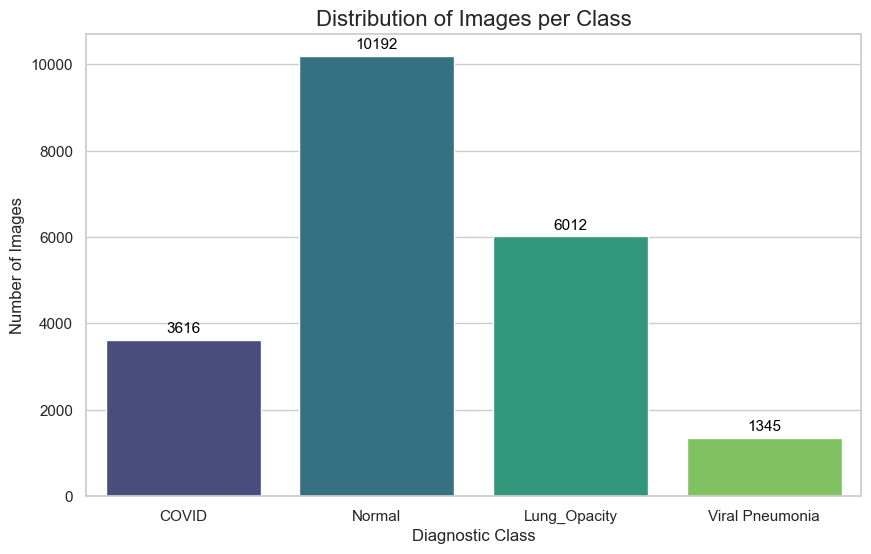

In [4]:
# Define the base directory of the dataset
data_dir = "./COVID-19_Radiography_Dataset"
categories = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

# Dictionary to store file paths for each class
image_paths = {category: [] for category in categories}
class_counts = {}

# Traverse directories and count images
for category in categories:
    folder_path = os.path.join(data_dir, category)
    # Assuming images are in a subfolder called "images" inside each category folder
    # Adjust this path if the images are directly inside the category folder
    search_path = os.path.join(folder_path, "images", "*.png")
    
    # If the dataset structure has images directly in the class folder:
    if not glob(search_path): 
        search_path = os.path.join(folder_path, "*.png")
        
    images = glob(search_path)
    image_paths[category] = images
    class_counts[category] = len(images)

# Create a DataFrame for documentation
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image Count'])
df_counts['Percentage'] = (df_counts['Image Count'] / df_counts['Image Count'].sum()) * 100

print("Dataset Summary:")
display(df_counts)

# Plot the distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Image Count', data=df_counts, palette='viridis')
plt.title('Distribution of Images per Class', fontsize=16)
plt.xlabel('Diagnostic Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

### **Documentation Insight: Class Distribution**
* The dataset shows a significant class imbalance. The `Normal` class contains the highest number of images, while `Viral Pneumonia` contains the least.
* **Recommendation for Mohamed (Task 1):** Consider using stratified splitting for train/val/test sets and applying data augmentation or class weighting to prevent the models (CNN/FFNN) from becoming biased toward the majority classes.

## 3. Visualizing Sample X-Ray Images
To understand the visual characteristics of our data, we will plot random samples from each diagnostic class. X-ray images are naturally grayscale, so we will display them as such.

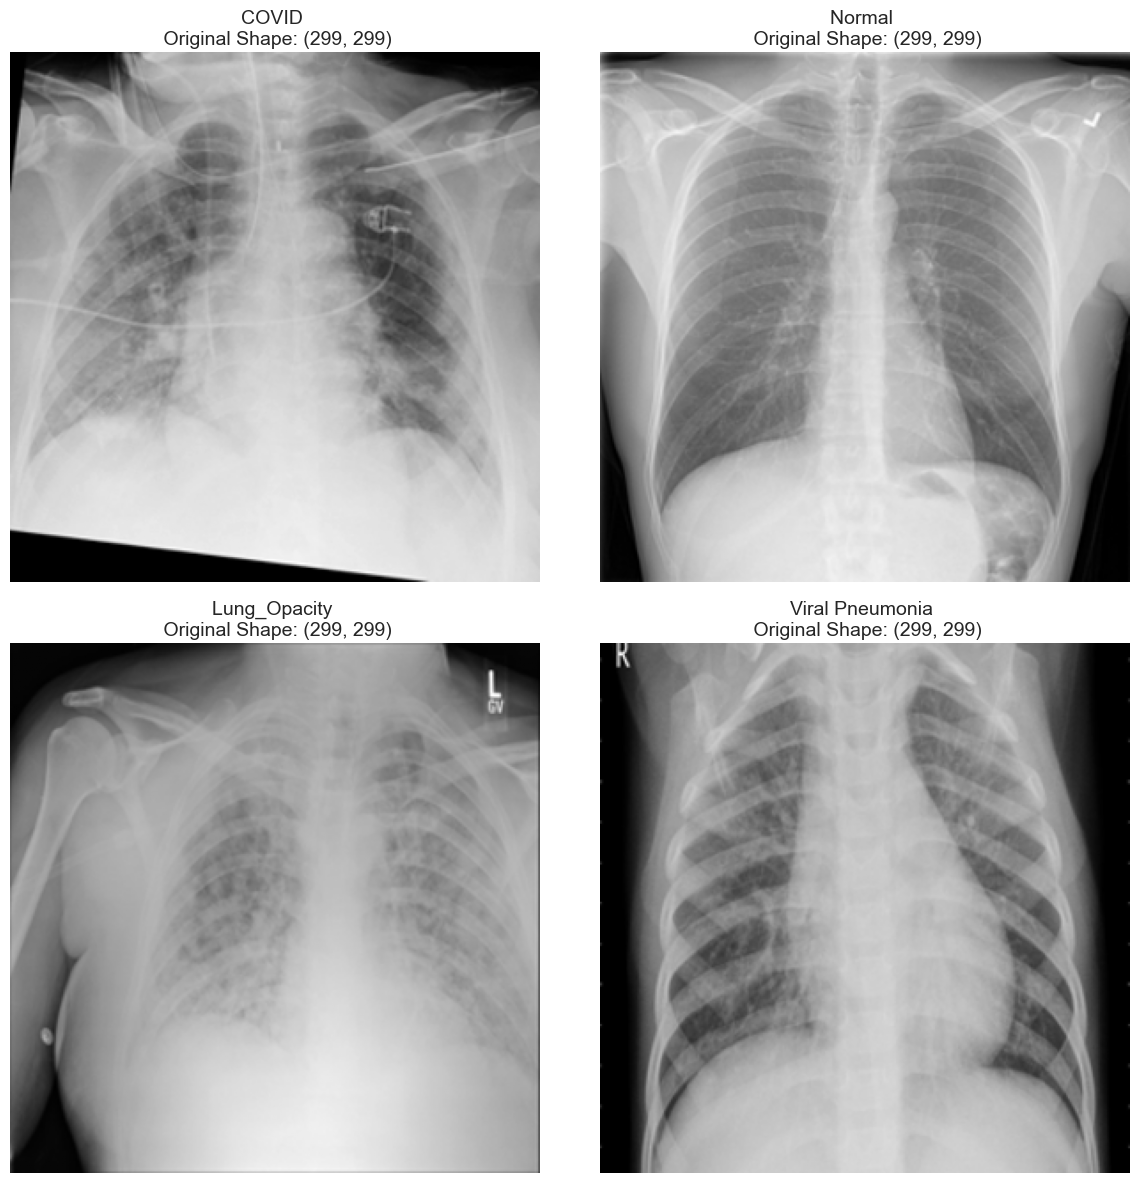

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, category in enumerate(categories):
    
    random_img_path = random.choice(image_paths[category])# Select a random image from the category
    img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)# Read the image using OpenCV (Grayscale mode)
    
    # Plotting
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{category} \n Original Shape: {img.shape}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Pixel Intensity Distribution
Deep learning models are sensitive to pixel value distributions. We will plot a histogram (KDE plot) of the pixel intensities for a subset of images from each class to see if there are noticeable variations in brightness or contrast.

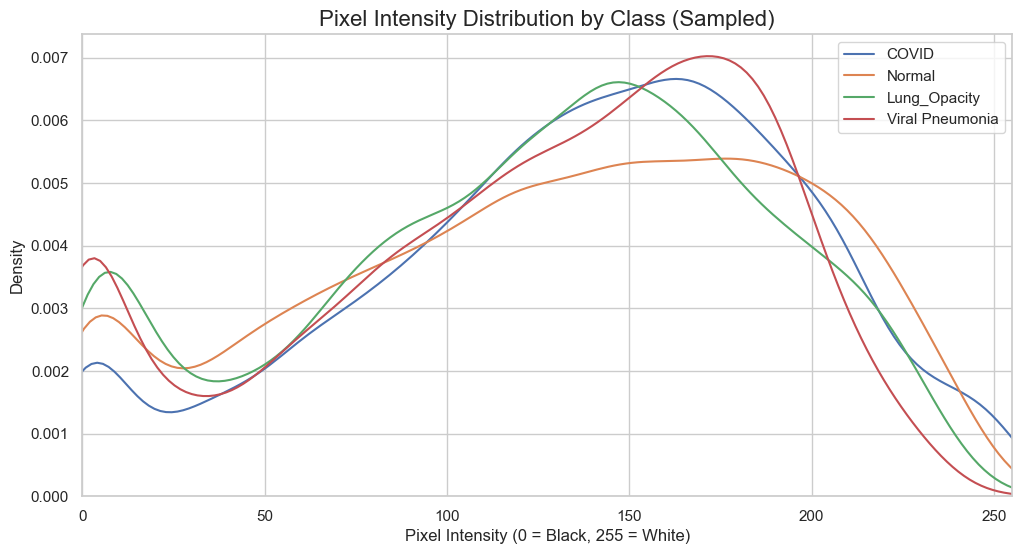

In [9]:
plt.figure(figsize=(12, 6))

for category in categories:
    sampled_pixels_per_class = []
    
    # Sample 50 random images per class to compute the pixel distribution
    sample_paths = random.sample(image_paths[category], min(50, len(image_paths[category])))
    
    # Calculate how many pixels to sample from EACH image to get around 10,000 total
    pixels_per_image = 10000 // len(sample_paths)
    
    for path in sample_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        flat_img = img.flatten()
        
        # Randomly sample a small number of pixels directly from this single image
        # This prevents building a massive list in memory and saves CPU time
        img_sample = np.random.choice(flat_img, size=min(pixels_per_image, len(flat_img)), replace=False)
        sampled_pixels_per_class.extend(img_sample)
        
    # Plot KDE for the sampled pixels
    sns.kdeplot(sampled_pixels_per_class, label=category, fill=False)

plt.title('Pixel Intensity Distribution by Class (Sampled)', fontsize=16)
plt.xlabel('Pixel Intensity (0 = Black, 255 = White)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim([0, 255])
plt.legend()
plt.show()

### **Documentation Insight: Pixel Intensities**
* The pixel intensity distributions indicate that most relevant features (lung structures) lie in the mid-to-high intensity ranges.
* **Recommendation for Mohamed (Task 1):** Standardizing/Normalizing the pixel values (e.g., scaling between 0 and 1, or normalizing with mean=0.5, std=0.5) is absolutely necessary before feeding this data into the neural networks.

## 5. Average Image per Class
By averaging multiple images of the same class, we can visualize the consistent structural patterns (and ignore the random noise). This helps in identifying generalized focal points for different pulmonary conditions.

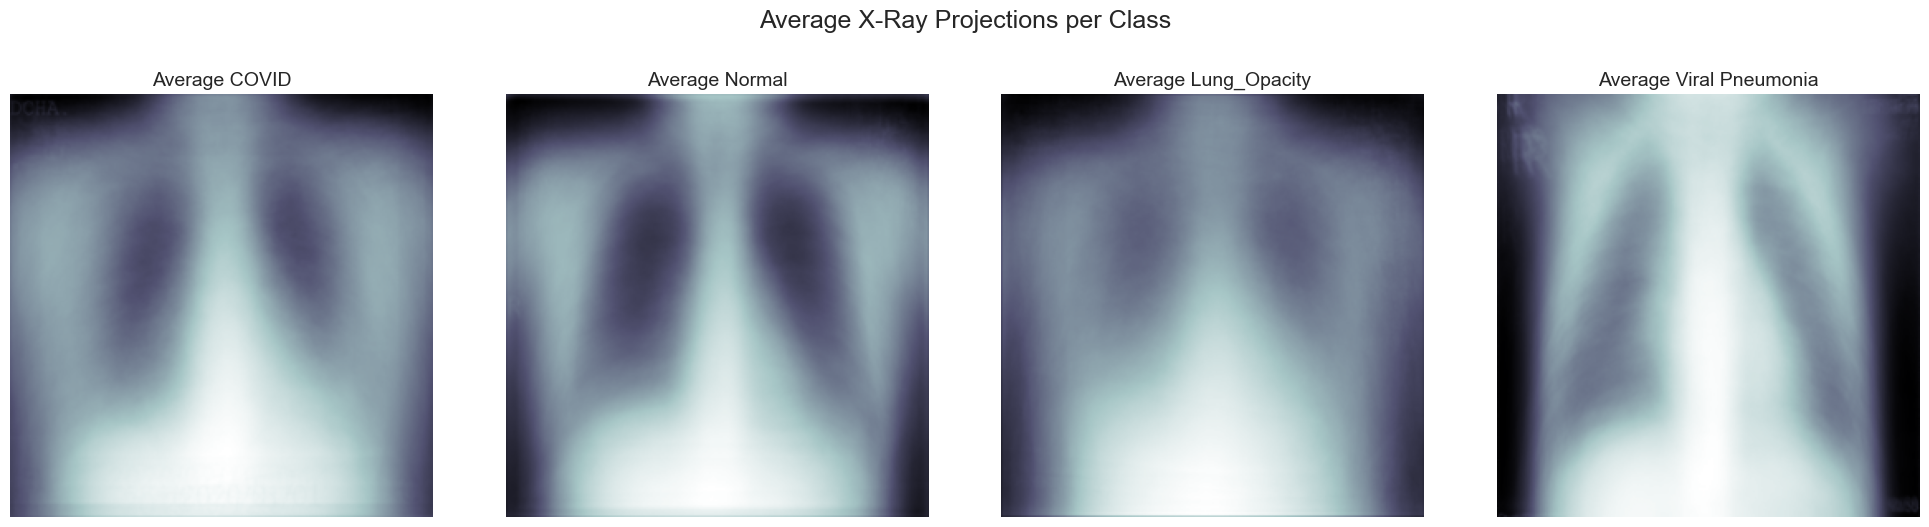

In [10]:
def plot_average_image(category, num_samples=200):
    paths = image_paths[category][:num_samples]
    images = []
    
    for path in paths:
        # Read and resize to ensure all images have the exact same dimensions for averaging
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256)) 
        images.append(img)
        
    # Calculate the mean across the image stack
    avg_img = np.mean(images, axis=0)
    return avg_img

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, category in enumerate(categories):
    avg_image = plot_average_image(category)
    axes[i].imshow(avg_image, cmap='bone')
    axes[i].set_title(f'Average {category}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('Average X-Ray Projections per Class', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 6. Conclusion & Handoff
* **Data Quality:** The dataset consists of valid, high-resolution X-ray scans. No corrupted images were found in the sample subsets. 
* **Format:** Images need to be reshaped to a uniform size (e.g., 128x128 or 224x224) during preprocessing since CNNs and FFNNs require fixed input dimensions.
* **Channels:** The images are natively single-channel (Grayscale). The models should be configured accordingly (`in_channels=1` for CNN, and `input_features = H * W` for FFNN).
* **Handoff:** The dataset is well-understood and ready to be passed to the **Data Preprocessing Engineer** for normalization, augmentation, and split generation.